In [4]:
!pip install contextily -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 54.9 MB/s eta 0:00:00


In [1]:
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, LinearRing
import contextily as ctx
import matplotlib.pyplot as plt

# Caminho do arquivo
input_path = "/content/poligono_teste.gpkg"
output_path = input_path.replace(".gpkg", "_sem_buracos_filtrados.gpkg")

# Limiar de área para os buracos
area_limite = 1e6

# Função para remover buracos pequenos
def remove_small_holes(geom, limite):
    if geom is None:
        return None

    if isinstance(geom, Polygon):
        # Mantém o exterior
        exterior = geom.exterior
        # Filtra interiores
        new_interiors = []
        for ring in geom.interiors:
            poly_hole = Polygon(ring)
            if poly_hole.area > limite:
                new_interiors.append(ring)
        return Polygon(exterior, new_interiors)

    elif isinstance(geom, MultiPolygon):
        return MultiPolygon([remove_small_holes(p, limite) for p in geom.geoms])

    return geom

# Carregar geopackage
gdf = gpd.read_file(input_path)
gdf = gdf.to_crs(epsg=5880)

# Aplicar
gdf["geometry"] = gdf["geometry"].apply(lambda g: remove_small_holes(g, area_limite))

# Salvar em novo arquivo
gdf.to_file(output_path, driver="GPKG")

print(f"Arquivo salvo em: {output_path}")

Arquivo salvo em: /content/poligono_teste_sem_buracos_filtrados.gpkg


In [18]:
# Função para visualização
def vis(gdf):
  fig, ax = plt.subplots(figsize=(15,10))
  gdf.plot(ax=ax)
  return ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, crs=gdf.crs)

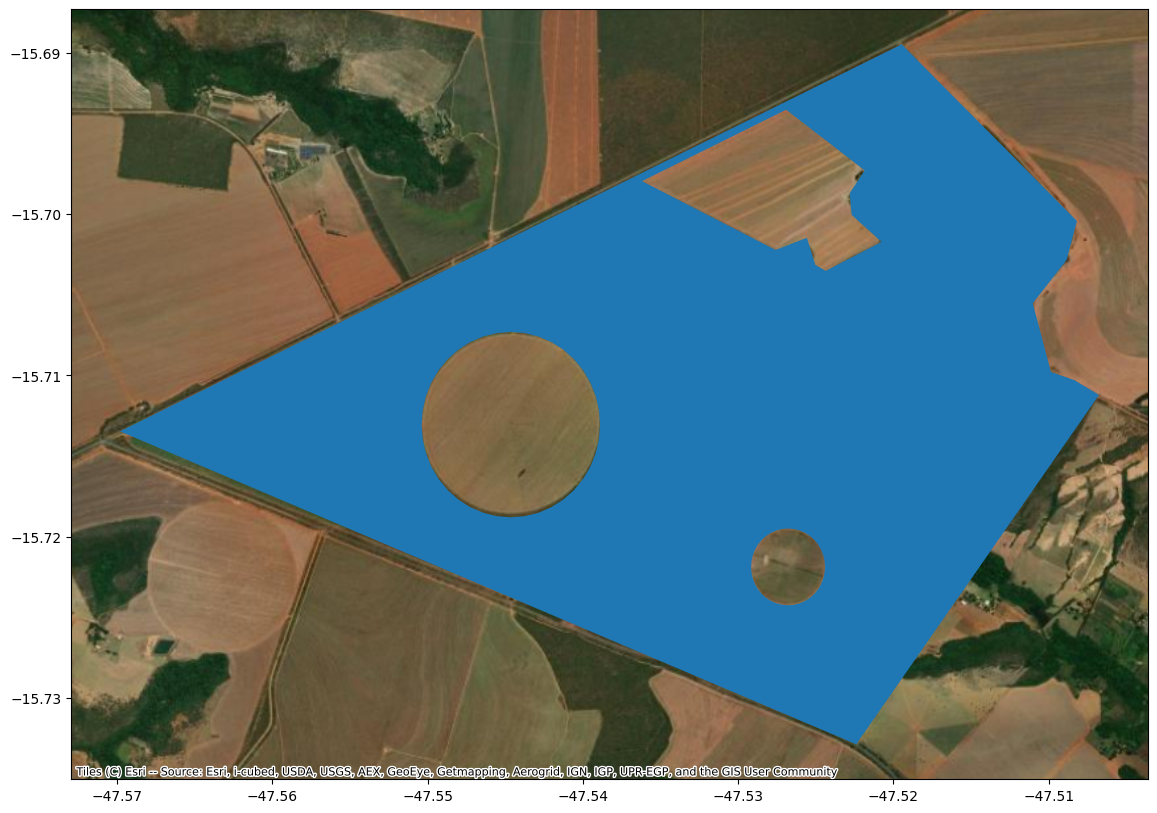

In [19]:
gdf1 = gpd.read_file('/content/poligono_teste.gpkg')
vis(gdf1)

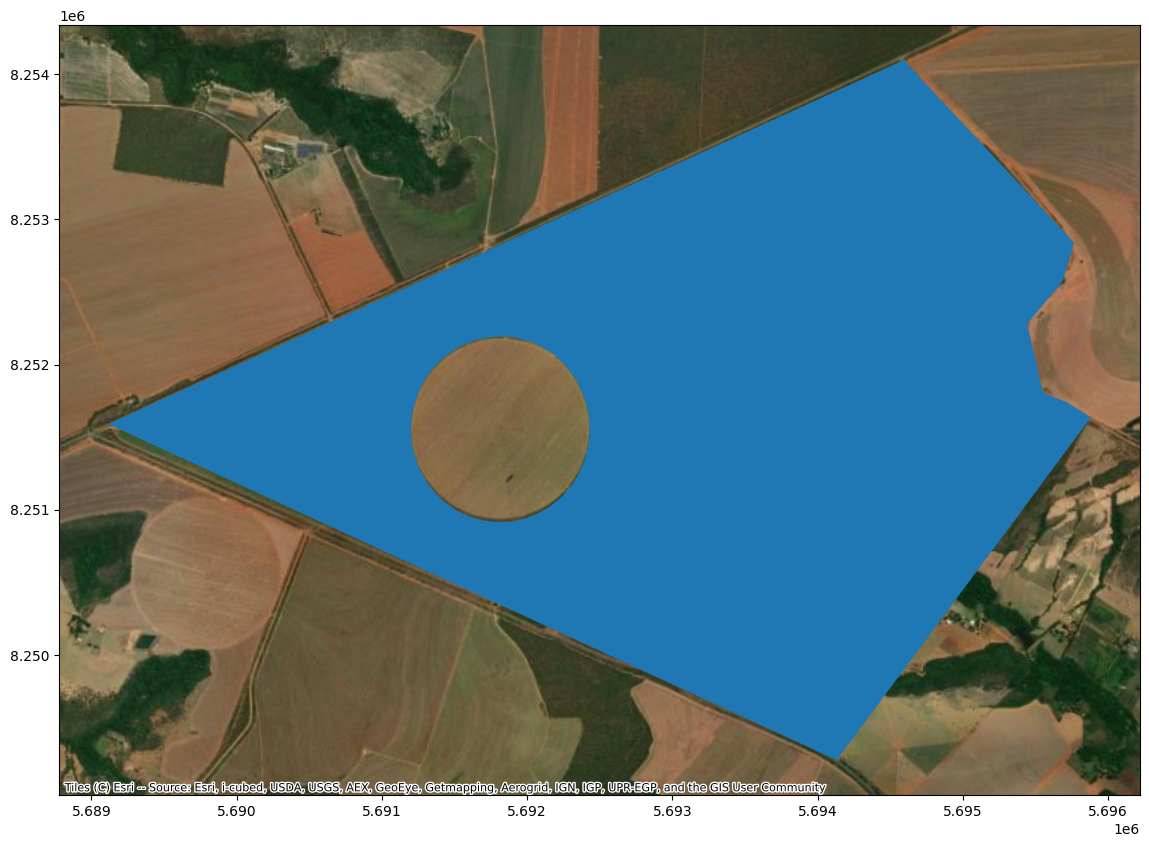

In [20]:
gdf2 = gpd.read_file('/content/poligono_teste_sem_buracos_filtrados.gpkg')
vis(gdf2)